<a href="https://colab.research.google.com/github/m42tk7246v-png/JCU_MA3832_Stephenson/blob/main/Dive_ch3_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Notes by Simon Stephenson

For *Dive Into Deep Learning, Chapter 3*

See notes for Chapter 2 for intro to my approach.



# 3.1 Linear Regression


In [2]:
!pip install --no-deps d2l

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 5.7 MB/s eta 0:00:00


In [5]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

## 3.1.1 Basics



Starting with

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$$

A the squared error in fitting a linear function is given by

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

Note the introduction of the $1/2$, which makes no difference to the parameters found, but is notationally convenient because it cancels after differentiation.

And hence a loss function:

$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} l^{(i)}(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2$$

When training the model, we seek parameters $(\mathbf{w}^*, b^*)$ that minimize the total loss across all training examples:

$$\mathbf{w}^*, b^* = \underset{\mathbf{w},b}{\argmin}\ L(\mathbf{w}, b)$$

which has analytic solution:
$$\mathbf{w}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$




Ok. Let's first implement this analytic solution.

Suppose $y = 2x_1 + 3x_2 + 4 + \epsilon$ where $\epsilon \sim N(0,1)$

In [33]:
import numpy as np
import time

# Set seed for reproducibility
np.random.seed(42)

# Generate sample data (n=10, 2 features)
n = 1000000
X_raw = np.random.uniform(0, 10, size=(n, 2))
w_true = np.array([2.0, 3.0])
b_true = 4.0
y = X_raw @ w_true + b_true + np.random.normal(0, 100, size=n)

# Build design matrix with bias column (column of ones)
X = np.hstack([X_raw, np.ones((n, 1))])  # shape (n, 3)

# Analytic solution: w* = (X^T X)^{-1} X^T y
start = time.perf_counter()
w_star = np.linalg.inv(X.T @ X) @ X.T @ y
elapsed = time.perf_counter() - start

w1_hat, w2_hat, b_hat = w_star

y_hat = X @ w_star
loss = (0.5 * (y_hat - y) ** 2).mean()

print(f"True parameters:      w1 = {w_true[0]}, w2 = {w_true[1]}, b = {b_true}")
print(f"Estimated parameters: w1 = {w1_hat:.3f}, w2 = {w2_hat:.3f}, b = {b_hat:.3f}")
print(f"Time elapsed: {elapsed:.3f} seconds")
print(f"Loss: {loss:.4f}")

True parameters:      w1 = 2.0, w2 = 3.0, b = 4.0
Estimated parameters: w1 = 2.035, w2 = 2.968, b = 4.095
Time elapsed: 0.037 seconds
Loss: 5003.5592


## 3.1.4 Minibatch Stochastic Gradient Descent



Ok. Before we go all minibatch, let's break this down.

First implement the code above for gradient descent:


In [32]:
import numpy as np
import time

# Set seed for reproducibility
np.random.seed(42)

# Generate sample data
n = 1000000
X_raw = np.random.uniform(0, 10, size=(n, 2))
w_true = np.array([2.0, 3.0])
b_true = 4.0
y = X_raw @ w_true + b_true + np.random.normal(0, 100, size=n)

# Gradient descent parameters
lr = 0.01
epochs = 100

# Initialise parameters
w = np.zeros(2)
b = 0.0

start = time.perf_counter()

for epoch in range(epochs):
    y_hat = X_raw @ w + b
    residuals = y_hat - y

    grad_w = (1 / n) * X_raw.T @ residuals
    grad_b = (1 / n) * residuals.sum()

    w -= lr * grad_w
    b -= lr * grad_b

    if (epoch + 1) % 10 == 0:
        loss = (0.5 * residuals ** 2).mean()
        print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | w1: {w[0]:.4f}, w2: {w[1]:.4f}, b: {b:.4f}")

elapsed = time.perf_counter() - start

print(f"\nTrue parameters:      w1 = {w_true[0]}, w2 = {w_true[1]}, b = {b_true}")
print(f"Estimated parameters: w1 = {w[0]:.3f}, w2 = {w[1]:.3f}, b = {b:.3f}")
print(f"Time elapsed: {elapsed:.3f} seconds")

Epoch  10 | Loss: 5004.8462 | w1: 2.5360, w2: 3.0781, b: 0.5337
Epoch  20 | Loss: 5004.5094 | w1: 2.4186, w2: 3.1876, b: 0.5837
Epoch  30 | Loss: 5004.4300 | w1: 2.3668, w2: 3.2310, b: 0.6328
Epoch  40 | Loss: 5004.3964 | w1: 2.3426, w2: 3.2468, b: 0.6813
Epoch  50 | Loss: 5004.3715 | w1: 2.3301, w2: 3.2511, b: 0.7291
Epoch  60 | Loss: 5004.3486 | w1: 2.3225, w2: 3.2505, b: 0.7762
Epoch  70 | Loss: 5004.3266 | w1: 2.3171, w2: 3.2480, b: 0.8226
Epoch  80 | Loss: 5004.3053 | w1: 2.3125, w2: 3.2447, b: 0.8684
Epoch  90 | Loss: 5004.2845 | w1: 2.3084, w2: 3.2411, b: 0.9136
Epoch 100 | Loss: 5004.2644 | w1: 2.3045, w2: 3.2374, b: 0.9581

True parameters:      w1 = 2.0, w2 = 3.0, b = 4.0
Estimated parameters: w1 = 2.304, w2 = 3.237, b = 0.958
Time elapsed: 3.107 seconds


Ok. Slow. Now go stochasatic:



In [34]:
import numpy as np
import time

# Set seed for reproducibility
np.random.seed(42)

n = 1000000
X_raw = np.random.uniform(0, 10, size=(n, 2))
w_true = np.array([2.0, 3.0])
b_true = 4.0
y = X_raw @ w_true + b_true + np.random.normal(0, 100, size=n)

# Hyperparameters
lr = 0.01
epochs = 5

# Initialise parameters
w = np.zeros(2)
b = 0.0

start = time.perf_counter()

for epoch in range(epochs):
    idx = np.random.permutation(n)
    X_shuf = X_raw[idx]
    y_shuf = y[idx]

    epoch_loss = 0.0
    for i in range(n):
        # Single sample
        x_i = X_shuf[i]       # shape (2,)
        y_i = y_shuf[i]       # scalar

        residual = x_i @ w + b - y_i

        # Update on single sample (|B| = 1, so no normalisation needed)
        w -= lr * residual * x_i
        b -= lr * residual

        epoch_loss += 0.5 * residual ** 2

    epoch_loss /= n
    print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f} | w1: {w[0]:.4f}, w2: {w[1]:.4f}, b: {b:.4f}")

elapsed = time.perf_counter() - start

print(f"\nTrue parameters:      w1 = {w_true[0]}, w2 = {w_true[1]}, b = {b_true}")
print(f"Estimated parameters: w1 = {w[0]:.3f}, w2 = {w[1]:.3f}, b = {b:.3f}")
print(f"Time elapsed: {elapsed:.3f} seconds")

Epoch   1 | Loss: 8219.3016 | w1: -3.4423, w2: 13.1810, b: 2.2345
Epoch   2 | Loss: 8205.0838 | w1: -3.8340, w2: 3.3495, b: 10.7076
Epoch   3 | Loss: 8207.5652 | w1: -6.6441, w2: 12.5459, b: 9.6445
Epoch   4 | Loss: 8199.2992 | w1: -3.1604, w2: -7.4319, b: 0.9398
Epoch   5 | Loss: 8210.4284 | w1: 1.8081, w2: 2.6893, b: 9.3889

True parameters:      w1 = 2.0, w2 = 3.0, b = 4.0
Estimated parameters: w1 = 1.808, w2 = 2.689, b = 9.389
Time elapsed: 31.327 seconds


Slow and worse performance again.

Now implement minibatch:

In [35]:
import numpy as np
import time

# Set seed for reproducibility
np.random.seed(42)

# Generate sample data
n = 1000000
X_raw = np.random.uniform(0, 10, size=(n, 2))
w_true = np.array([2.0, 3.0])
b_true = 4.0
y = X_raw @ w_true + b_true + np.random.normal(0, 100, size=n)

# Hyperparameters
lr = 0.01        # eta
batch_size = 256  # |B|
epochs = 10

# Initialise parameters
w = np.zeros(2)
b = 0.0

n_batches = n // batch_size
start = time.perf_counter()

for epoch in range(epochs):
    # Randomly sample minibatches by shuffling indices
    idx = np.random.permutation(n)
    X_shuf = X_raw[idx]
    y_shuf = y[idx]

    epoch_loss = 0.0
    for t in range(n_batches):
        # Sample minibatch B_t
        X_B = X_shuf[t * batch_size:(t + 1) * batch_size]  # shape (|B|, 2)
        y_B = y_shuf[t * batch_size:(t + 1) * batch_size]  # shape (|B|,)

        # Residuals: w^T x^(i) + b - y^(i)  for each i in B_t
        residuals = X_B @ w + b - y_B

        # Update rule (3.1.11):
        # w <- w - (eta / |B|) * sum_{i in B_t} x^(i) (w^T x^(i) + b - y^(i))
        # b <- b - (eta / |B|) * sum_{i in B_t} (w^T x^(i) + b - y^(i))
        w -= (lr / batch_size) * X_B.T @ residuals
        b -= (lr / batch_size) * residuals.sum()

        epoch_loss += (0.5 * residuals ** 2).mean()

    epoch_loss /= n_batches
    print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f} | w1: {w[0]:.4f}, w2: {w[1]:.4f}, b: {b:.4f}")

elapsed = time.perf_counter() - start

print(f"\nTrue parameters:      w1 = {w_true[0]}, w2 = {w_true[1]}, b = {b_true}")
print(f"Estimated parameters: w1 = {w[0]:.3f}, w2 = {w[1]:.3f}, b = {b:.3f}")
print(f"Time elapsed: {elapsed:.3f} seconds")

Epoch   1 | Loss: 5012.7861 | w1: 1.6969, w2: 2.5177, b: 4.0649
Epoch   2 | Loss: 5012.3208 | w1: 1.8033, w2: 2.7899, b: 4.5756
Epoch   3 | Loss: 5013.0838 | w1: 2.4397, w2: 3.0905, b: 3.6658
Epoch   4 | Loss: 5012.7407 | w1: 2.4803, w2: 2.6938, b: 4.6819
Epoch   5 | Loss: 5012.3425 | w1: 1.3399, w2: 3.0556, b: 3.7021
Epoch   6 | Loss: 5012.9076 | w1: 1.8442, w2: 2.1990, b: 3.7272
Epoch   7 | Loss: 5012.8635 | w1: 2.4080, w2: 3.1370, b: 3.8793
Epoch   8 | Loss: 5012.7315 | w1: 2.2534, w2: 3.6920, b: 4.0814
Epoch   9 | Loss: 5012.7703 | w1: 2.5893, w2: 3.1191, b: 3.5965
Epoch  10 | Loss: 5012.7152 | w1: 2.4602, w2: 3.8187, b: 4.4866

True parameters:      w1 = 2.0, w2 = 3.0, b = 4.0
Estimated parameters: w1 = 2.460, w2 = 3.819, b = 4.487
Time elapsed: 3.866 seconds


Hmm. Not impressive. How to tune the parameters?

Let's focus on learning rate

## Learning Rate Optimisation

For theoretical reasons, the upper bound on the learning rate is derived from the
curvature of the loss surface. For least-squares linear regression the loss is a
quadratic bowl, and its curvature is described by the Hessian:

$$H = \frac{1}{n} X^\top X$$

Gradient descent contracts toward the minimum only if the learning rate satisfies:

$$\eta < \frac{2}{\lambda_{\max}(H)}$$

where $\lambda_{\max}(H)$ is the largest eigenvalue of the feature covariance matrix.
Intuitively, a large eigenvalue means the loss rises steeply in that direction —
a step that is too large will overshoot and diverge.

### Computing the bound for this problem

With $x_1, x_2 \sim \text{Uniform}(0, 10)$ and independent features, the expected
feature covariance matrix is:

$$H \approx \begin{pmatrix} \mathbb{E}[x_1^2] & \mathbb{E}[x_1 x_2] \\ \mathbb{E}[x_1 x_2] & \mathbb{E}[x_2^2] \end{pmatrix} = \begin{pmatrix} 33.3 & 25.0 \\ 25.0 & 33.3 \end{pmatrix}$$

For a $2 \times 2$ symmetric matrix with equal diagonal entries $a$ and off-diagonal
entries $b$, the eigenvalues are $a \pm b$, so:

$$\lambda_{\max} = 33.3 + 25.0 = 58.3$$

This gives an upper bound of:

$$\eta < \frac{2}{58.3} \approx 0.034$$



> **Note:** This bound is derived for full-batch gradient descent. Minibatch SGD
> introduces gradient noise, so in practice the effective safe learning rate is
> somewhat lower than the theoretical maximum.

Let's do a sweep over the learning rate:

In [36]:
import numpy as np
import time

np.random.seed(42)

# Generate sample data
n = 1000000
X_raw = np.random.uniform(0, 10, size=(n, 2))
w_true = np.array([2.0, 3.0])
b_true = 4.0
y = X_raw @ w_true + b_true + np.random.normal(0, 100, size=n)

# Hyperparameters
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
batch_size = 256
epochs = 10

n_batches = n // batch_size


def run_sgd(lr, seed=0):
    rng = np.random.default_rng(seed)
    w = np.zeros(2)
    b = 0.0
    loss_history = []

    for epoch in range(epochs):
        idx = rng.permutation(n)
        X_shuf = X_raw[idx]
        y_shuf = y[idx]

        epoch_loss = 0.0
        for t in range(n_batches):
            X_B = X_shuf[t * batch_size:(t + 1) * batch_size]
            y_B = y_shuf[t * batch_size:(t + 1) * batch_size]

            residuals = X_B @ w + b - y_B
            w -= (lr / batch_size) * X_B.T @ residuals
            b -= (lr / batch_size) * residuals.sum()

            epoch_loss += (0.5 * residuals ** 2).mean()

        loss_history.append(epoch_loss / n_batches)

        if not np.isfinite(loss_history[-1]):
            break  # diverged — no point continuing

    return w, b, loss_history


print(f"batch_size={batch_size}, epochs={epochs}\n")
print(f"{'lr':>8} | {'Loss (ep 1)':>12} | {'Loss (final)':>12} | {'w1':>7} {'w2':>7} {'b':>7} | {'Status'}")
print("-" * 78)

for lr in learning_rates:
    start = time.perf_counter()
    w, b, history = run_sgd(lr)
    elapsed = time.perf_counter() - start

    ok = np.isfinite(history[-1])
    status = f"ok ({elapsed:.1f}s)" if ok else "DIVERGED"
    final_loss = history[-1] if ok else float("nan")

    print(f"{lr:>8.0e} | {history[0]:>12.2f} | {final_loss:>12.2f} | {w[0]:>7.3f} {w[1]:>7.3f} {b:>7.3f} | {status}")

print(f"\nTrue: w1={w_true[0]}, w2={w_true[1]}, b={b_true}")

batch_size=256, epochs=10

      lr |  Loss (ep 1) | Loss (final) |      w1      w2       b | Status
------------------------------------------------------------------------------
   1e-04 |      5015.03 |      5003.90 |   2.148   3.162   2.007 | ok (3.9s)
   1e-03 |      5005.97 |      5004.24 |   1.883   2.914   4.076 | ok (2.7s)
   1e-02 |      5013.18 |      5012.99 |   1.326   1.937   3.952 | ok (2.7s)
   1e-01 |          nan |          nan |     nan     nan     nan | DIVERGED

True: w1=2.0, w2=3.0, b=4.0


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2967/535804274.py:41: RuntimeWarning: overflow encountered in square
  epoch_loss += (0.5 * residuals ** 2).mean()
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/tmp/ipykernel_2967/535804274.py:39: RuntimeWarning: invalid value encountered in scalar subtract
  b -= (lr / batch_size) * residuals.sum()


## Learning Rate Sweep: Interpretation and Implications

### Results summary

| `lr` | Final loss | w1 | w2 | b | Verdict |
|------|-----------|-----|-----|---|---------|
| 1e-4 | 5003.90 | 2.148 | 3.162 | 2.007 | Too small — slow convergence |
| 1e-3 | 5004.24 | 1.883 | 2.914 | 4.076 | **Best** |
| 1e-2 | 5012.99 | 1.326 | 1.937 | 3.952 | Near instability — oscillating |
| 1e-1 | NaN | NaN | NaN | NaN | Diverged |

### Key observations

**`lr=1e-3` is the sweet spot.** It recovers the true parameters most accurately and reaches the lowest final loss.

**`lr=1e-4` is too small.** The weights are reasonable but `b=2.007` is still far from the true value of 4.0 after 10 epochs — the bias hasn't converged. Given more epochs it would get there, but progress is slow.

**`lr=1e-2` is counterintuitively *worse* than `lr=1e-3`.** The loss barely moved (5013 → 5012) and the parameter estimates are the furthest off of the three converged runs. This is because `lr=1e-2` is near the instability boundary (~0.034) so it is oscillating rather than making clean progress. A larger learning rate does not always mean faster convergence.

**`lr=1e-1` diverges**, as predicted by the eigenvalue bound.

### The noise floor

All converged runs plateau near a loss of **~5000**. This is not a coincidence — with noise σ = 100, the irreducible Bayes-optimal loss is 0.5 × σ² = 5000. No learning rate can beat this. As a consequence, **final loss alone cannot distinguish between learning rates** once you are near the noise floor — you must inspect the parameter estimates directly.

### Practical rule

Choose the largest learning rate that still converges stably. Here, that is `lr=1e-3`.

*Ok. How it practice does one use this kind of sweep for learning rate? By doing it on a subset of the data before running the real algorithm?*

## Choosing a Learning Rate in Practice

Yes, that is the standard approach — run the sweep on a small representative subset
(say 5–10% of the data) for fewer epochs, since you are just trying to identify the
stable region, not fit a final model. The assumption is that the loss landscape does
not change dramatically with more data, which holds for well-shuffled data from the
same distribution.

A more principled variant is the **learning rate range test** (Leslie Smith, 2015):
train for a single pass while increasing $\eta$ exponentially from very small to very
large, plot loss vs $\eta$, and pick the value just *before* the loss starts rising.
This is faster than a full grid sweep and gives a continuous picture rather than a few
discrete points. It is built into libraries like PyTorch Lightning as `lr_find()`.

For a convex problem like least-squares regression the analytical bound is cheap to
compute and arguably better than either empirical approach:

$$\eta < \frac{2}{\lambda_{\max}(X^\top X / n)}$$

But in deep learning the loss surface is not convex, so the empirical sweep or range
test is necessary.

### Summary

| Approach | When to use |
|---|---|
| Analytical bound | Convex problems (e.g. linear/logistic regression) |
| Subset sweep | General purpose; interpretable; easy to implement |
| LR range test | Deep learning; fast single-pass diagnostic |



## 3.1.1.5 Predictions

Given parameters $\hat{w}, \hat{b}$ one can make predictions $\hat{w}^Tx + \hat{b}$, a la good old statistics.

DL practitioners have developed the habit of calling the prediction phase *inference*, which is unfortunate but good to know so you can talk to them. We will try to stick to *prediction*.



## 3.1.2 Vectorisation for Speed

We have already discussed in 2.5 question 4 the advantages of vectorisation. Here's a concrete example:

In [37]:
n = 10000
a = torch.ones(n)
b = torch.ones(n)

In [38]:
c = torch.zeros(n)
t = time.time()
for i in range(n):
    c[i] = a[i] + b[i]
f'{time.time() - t:.5f} sec'

'0.18387 sec'

In [39]:
t = time.time()
d = a + b
f'{time.time() - t:.5f} sec'

'0.00122 sec'

Sure enough. In the runs in front of me the vectorised version runs more than 100 times faster.

## 3.1.3 The Normal Distribution and Squared Loss

In [40]:
# Normal pdf from first principles
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)

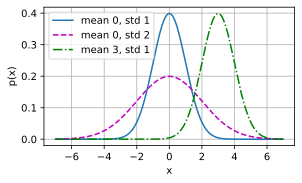

In [41]:
# Use NumPy again for visualization
x = np.arange(-7, 7, 0.01)

# Mean and standard deviation pairs
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

Ahh, this example is nice. I can begin to see now why the d2l version of plot could be preferred.

Nice technical discussion in the text, the conclusion of which is the following:

**Maximising the likelihood of the entire dataset is equivalent to
minimising the negative log-likelihood, which in turn — under the
assumption of Gaussian noise — reduces to minimising the mean squared
error. The simple procedure of least squares is therefore not merely a
computational convenience: it is the maximum likelihood estimator in
disguise.**

## 3.1.4 Linear Regression as a Neural Network

We can think of linear regression as single layer neural network:

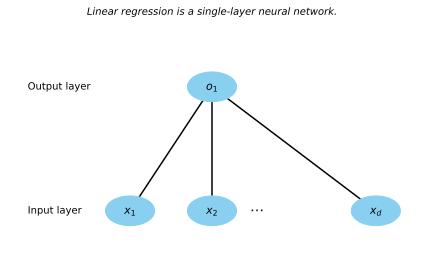

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Node positions
input_nodes = [(0.3, 0.25), (0.5, 0.25), (0.9, 0.25)]  # x1, x2, xd
output_node = (0.5, 0.75)

node_radius = 0.06
node_color = '#89CFF0'

# Draw arrows from input to output (behind nodes)
for (x, y) in input_nodes:
    ax.annotate("", xy=output_node, xytext=(x, y),
                arrowprops=dict(arrowstyle="-|>", color='black', lw=1.5))

# Draw input nodes
for (x, y), label in zip(input_nodes, [r'$x_1$', r'$x_2$', r'$x_d$']):
    circle = plt.Circle((x, y), node_radius, color=node_color, zorder=3)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=11, zorder=4)

# Draw output node
circle = plt.Circle(output_node, node_radius, color=node_color, zorder=3)
ax.add_patch(circle)
ax.text(*output_node, r'$o_1$', ha='center', va='center', fontsize=11, zorder=4)

# Ellipsis between x2 and xd
ax.text(0.61, 0.25, r'$\cdots$', ha='center', va='center', fontsize=14)

# Layer labels
ax.text(0.05, 0.25, 'Input layer', ha='left', va='center', fontsize=10)
ax.text(0.05, 0.75, 'Output layer', ha='left', va='center', fontsize=10)

ax.set_title('Linear regression is a single-layer neural network.',
             fontsize=10, style='italic', pad=10)

plt.tight_layout()
plt.show()

## 3.2 Object-Oriented Design for Implementation



The help optimise implementation, we are going to create and use three classes

1. `Module` which contains models, losses, and optimisation methods

2. `DataModule` which provides data loaders for training and validation

3. `Trainer`, which calls the two previous and allows us to train


In [46]:
!pip install --no-deps d2l

In [72]:
import time
import numpy as np
import torch
import random
from torch import nn
from d2l import torch as d2l

To make it easier to show how classes are built up, we build a utility function that enables us to add a function as a method in a previous created class. We can either define it ourselves as below OR call it as `d2l.add_to_class`.

An example of its use:

In [52]:
def add_to_class(Class):
    """Register functions as methods in created class."""
    def wrapper(obj):
        setattr(Class, obj.__name__, obj)
    return wrapper

In [48]:
class A:
    def __init__(self):
        self.b = 1

a = A()

In [53]:
a.do()

AttributeError: 'A' object has no attribute 'do'

In [54]:
@add_to_class(A)
def do(self):
    print('Class attribute "b" is', self.b)

a.do()

Class attribute "b" is 1


In [58]:
# OR
@d2l.add_to_class(A)
def do(self):
    print('VERSION 2: Class attribute "b" is', self.b)

a.do()

VERSION 2: Class attribute "b" is 1


In [55]:
class HyperParameters:
    """The base class of hyperparameters."""
    def save_hyperparameters(self, ignore=[]):
        raise NotImplemented

In [56]:
# Build an example class on a fully implemented HyperParameters class saved in d2l
class B(d2l.HyperParameters):
    def __init__(self, a, b, c):
        self.save_hyperparameters(ignore=['c'])
        print('self.a =', self.a, 'self.b =', self.b)
        print('There is no self.c =', not hasattr(self, 'c'))

b = B(a=1, b=2, c=3)

self.a = 1 self.b = 2
There is no self.c = True


There's also a utility that allows us to plot experiment progress interactively, called `d2l.ProgressBoard`. Example:



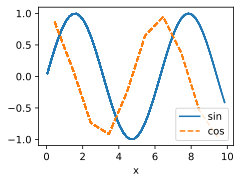

In [60]:
board = d2l.ProgressBoard('x')
for x in np.arange(0, 10, 0.1):
    board.draw(x, np.sin(x), 'sin', every_n=2)
    board.draw(x, np.cos(x), 'cos', every_n=10)

## 3.2.2 Models

Class `Module`.

In [ ]:
# The base class for all models in d2l. Inherits from both:
#   - nn.Module: PyTorch's base class for all neural networks, which
#                provides parameter tracking, forward() wiring, etc.
#   - d2l.HyperParameters: provides save_hyperparameters()
class Module(nn.Module, d2l.HyperParameters):
    """The base class of models."""

    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        # Must call both parent constructors. super().__init__() here
        # triggers nn.Module's constructor via Python's MRO (method
        # resolution order) for multiple inheritance.
        super().__init__()

        # Save plot_train_per_epoch and plot_valid_per_epoch as attributes.
        self.save_hyperparameters()

        # Create the animated plotting board that will display the loss
        # curve updating in real time during training.
        self.board = ProgressBoard()

    def loss(self, y_hat, y):
        # Stub — every subclass must override this with its own loss function.
        # For linear regression this is MSE; for other models it will differ.
        raise NotImplementedError

    def forward(self, X):
        # Default forward pass: delegates to self.net, which subclasses
        # are expected to define (e.g. an nn.Linear layer).
        # The assert gives a clear error message if a subclass forgot to
        # define self.net.
        assert hasattr(self, 'net'), 'Neural network is defined'
        return self.net(X)

    def plot(self, key, value, train):
        """Plot a point in animation."""
        # Requires a Trainer to be attached — the Trainer sets self.trainer
        # on the model when fit() is called.
        assert hasattr(self, 'trainer'), 'Trainer is not inited'
        self.board.xlabel = 'epoch'

        if train:
            # For training, x is a fractional epoch position — e.g. halfway
            # through epoch 2 gives x=2.5. This lets us see loss evolving
            # within an epoch, not just at the end of each one.
            x = self.trainer.train_batch_idx / \
                self.trainer.num_train_batches
            # Plot every n batches, where n is chosen so that we get
            # exactly plot_train_per_epoch points per epoch.
            n = self.trainer.num_train_batches / \
                self.plot_train_per_epoch
        else:
            # For validation, x is simply the epoch number (integers).
            # Validation runs once per epoch so fractional positions
            # are not needed.
            x = self.trainer.epoch + 1
            n = self.trainer.num_val_batches / \
                self.plot_valid_per_epoch

        # Detach the value from the computation graph (we don't need
        # gradients for plotting), move to CPU, convert to numpy,
        # and hand to the ProgressBoard to draw.
        # The label is prefixed with 'train_' or 'val_' so both curves
        # can appear on the same plot.
        self.board.draw(x, value.to(d2l.cpu()).detach().numpy(),
                        ('train_' if train else 'val_') + key,
                        every_n=int(n))

    def training_step(self, batch):
        # Called once per minibatch during training.
        # batch is a list/tuple of tensors; by convention the last element
        # is y (the targets) and everything before it is X (the features).
        # self(*batch[:-1]) calls forward() on the features to get y_hat.
        l = self.loss(self(*batch[:-1]), batch[-1])

        # Log the training loss to the animated plot.
        self.plot('loss', l, train=True)
        return l

    def validation_step(self, batch):
        # Same as training_step but for validation — compute loss and plot,
        # but return nothing (no backward pass will be done on this).
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)

    def configure_optimizers(self):
        # Stub — subclasses must override this to return their chosen
        # optimizer (e.g. SGD, Adam) configured with the right parameters.
        raise NotImplementedError

## 3.2.3 Data

Ditto `DataModule`.

In [101]:
# Base class for all datasets in d2l. Inherits save_hyperparameters()
# from d2l.HyperParameters.
class DataModule(d2l.HyperParameters):
    """The base class of data."""

    def __init__(self, root='../data', num_workers=4):
        # root: where to look for / download datasets on disk
        # num_workers: how many parallel CPU workers the DataLoader
        #              will use to load batches in the background
        # Both are saved as self.root and self.num_workers.
        self.save_hyperparameters()

    def get_dataloader(self, train):
        # Stub — subclasses must override this to return an actual
        # DataLoader for either the training or validation split.
        # The train flag tells the subclass which split to return.
        raise NotImplementedError

    def train_dataloader(self):
        # Returns a DataLoader for the training split.
        # Delegates to get_dataloader() with train=True, which the
        # subclass has overridden with the real implementation.
        return self.get_dataloader(train=True)

    def val_dataloader(self):
        # Returns a DataLoader for the validation split.
        # Delegates to get_dataloader() with train=False.
        return self.get_dataloader(train=False)

## 3.2.4 Training

Ditto `Trainer`.

In [ ]:
# The base class that owns and runs the training loop.
# Inherits save_hyperparameters() from d2l.HyperParameters.
class Trainer(d2l.HyperParameters):
    """The base class for training models with data."""

    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        # max_epochs: how many full passes through the training data to run
        # num_gpus: GPU support not yet implemented — must be 0
        # gradient_clip_val: threshold for gradient clipping (0 = disabled)
        # All three saved as attributes via save_hyperparameters().
        self.save_hyperparameters()
        assert num_gpus == 0, 'No GPU support yet'

    def prepare_data(self, data):
        # Pull the training and validation DataLoaders out of the data module
        # and attach them to the Trainer so fit_epoch() can iterate over them.
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()

        # Count the number of batches in each split. These are used by
        # Module.plot() to compute fractional epoch positions for the
        # animated loss curve, and by val_dataloader to handle the case
        # where there is no validation set.
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = (len(self.val_dataloader)
                                if self.val_dataloader is not None else 0)

    def prepare_model(self, model):
        # Attach the Trainer to the model so that Module.plot() can access
        # training state (epoch, batch index, etc.) during the training loop.
        model.trainer = self

        # Set the x-axis limit of the progress board to max_epochs so the
        # animated plot is scaled correctly from the start.
        model.board.xlim = [0, self.max_epochs]

        # Attach the model to the Trainer so fit_epoch() can call it.
        self.model = model

    def fit(self, model, data):
        # Entry point for training. Sets everything up and runs the loop.

        # Wire up the DataLoaders and count batches.
        self.prepare_data(data)

        # Wire up the model and configure the plot board.
        self.prepare_model(model)

        # Ask the model to create and return its optimizer (e.g. SGD).
        # configure_optimizers() is a stub in Module that subclasses override.
        self.optim = model.configure_optimizers()

        # Initialise counters used for plotting and progress tracking.
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0

        # Run fit_epoch() once per epoch. self.epoch is updated each iteration
        # so that Module.plot() and fit_epoch() always know the current epoch.
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

    def fit_epoch(self):
        # Stub — the actual per-epoch training and validation logic is
        # defined by monkey-patching this method onto d2l.Trainer in
        # Section 3.4.4 (the fit_epoch code we commented earlier).
        raise NotImplementedError

## 3.2.5 Summary

Why all this abstration? It creates a plug-and-play framework that will make everything that follows easier. Apparently. We shall see!


## 3.3 Synthetic Regression Data

Hmm, looks like we are about to do what I already implemented myself, except it is now in tensor implementation. Let us see.

Ok. Looking at class `SyntheticRegressionData` it is more than just tensor implementation. It is more sophisticated, including training and validation data. We are setting up ways of thinking that will translate to more sophisticated models later.





In [63]:
class SyntheticRegressionData(d2l.DataModule):
    """Synthetic data for linear regression."""
    def __init__(self, w, b, noise=0.01, num_train=1000, num_val=1000,
                 batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, len(w))
        noise = torch.randn(n, 1) * noise
        self.y = torch.matmul(self.X, w.reshape((-1, 1))) + b + noise

In [68]:
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)

In [65]:
print('features:', data.X[0],'\nlabel:', data.y[0])

features: tensor([-0.3419,  1.3569]) 
label: tensor([-1.0833])


Ok. Lovely. Let's recreate the regression dataset from above using this new function.


In [ ]:
data = SyntheticRegressionData(
    w=torch.tensor([2.0, 3.0]),
    b=4.0,
    noise=100,
    num_train=500_000,
    num_val=500_000,
    batch_size=256
)

# Two mismatches. First X here draws from torch.randn while my original drew
# from Uniform(0,10). Second, here the 1_000_000 are split 50/50 into training
# and validation data sets

All right good. Now let's restore the textbook version of data so the rest of the code below isn't broken:

In [69]:
# To clarify, this is an object that has inherited methods from class DataModule
# and from its predecessor Hyperparameters
data = SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)

## 3.3.2 Reading the Dataset



In [70]:
@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    if train:
        indices = list(range(0, self.num_train))
        # The examples are read in random order
        random.shuffle(indices)
    else:
        indices = list(range(self.num_train, self.num_train+self.num_val))
    for i in range(0, len(indices), self.batch_size):
        batch_indices = torch.tensor(indices[i: i+self.batch_size])
        yield self.X[batch_indices], self.y[batch_indices]

## `yield` and Generator Functions

`yield` makes `get_dataloader` a **generator function**. Instead of building all
batches and returning them at once, it produces one batch at a time — pausing
execution after each `yield`, and resuming from that point when the next batch
is requested.

So instead of this (loads everything into memory at once):

```python
return [(X[b], y[b]) for b in all_batches]  # list of all batches
```

It does this:

```python
yield self.X[batch_indices], self.y[batch_indices]  # one batch, then pause
```

The practical consequence is that at any moment only one batch lives in memory,
not the entire dataset. For a 1M-row dataset that matters.

You call it the same way as a list — a `for` loop just triggers the next `yield`
each iteration:

```python
for X_batch, y_batch in data.get_dataloader(train=True):
    # only one batch in memory here
```

The connection to manual minibatch SGD: the shuffle-then-slice loop in a standard
NumPy implementation is doing exactly the same thing as this generator, just
without the `yield`.

In [73]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


In [102]:
import inspect
inspect.getsource(data.train_dataloader)

'    def train_dataloader(self):\n        return self.get_dataloader(train=True)\n'

All right then. `data.train_dataloader()` returns an object of class `DataLoader`.

`iter(...)` activates this object, turning it into an Python iterator ready to yield batches.

`next(...)` asks for the first batch.

So this whole line is saying "start up the dataloader and grab the first minibatch". All we are doing with it right now is inspecting its shape.

In real training, we would never write the code this way. Instead we would just loop using
```python
for X, y in data.train_dataloader():
```



Hmm .. let me make sure I know where everything lives...

In [75]:
import inspect
inspect.getsource(d2l.DataModule)

'class DataModule(d2l.HyperParameters):\n    """The base class of data.\n\n    Defined in :numref:`subsec_oo-design-models`"""\n    def __init__(self, root=\'../data\', num_workers=4):\n        self.save_hyperparameters()\n\n    def get_dataloader(self, train):\n        raise NotImplementedError\n\n    def train_dataloader(self):\n        return self.get_dataloader(train=True)\n\n    def val_dataloader(self):\n        return self.get_dataloader(train=False)\n\n    def get_tensorloader(self, tensors, train, indices=slice(0, None)):\n        """Defined in :numref:`sec_synthetic-regression-data`"""\n        tensors = tuple(a[indices] for a in tensors)\n        dataset = torch.utils.data.TensorDataset(*tensors)\n        return torch.utils.data.DataLoader(dataset, self.batch_size,\n                                           shuffle=train)\n'

Ok, my best guess right now is the following:
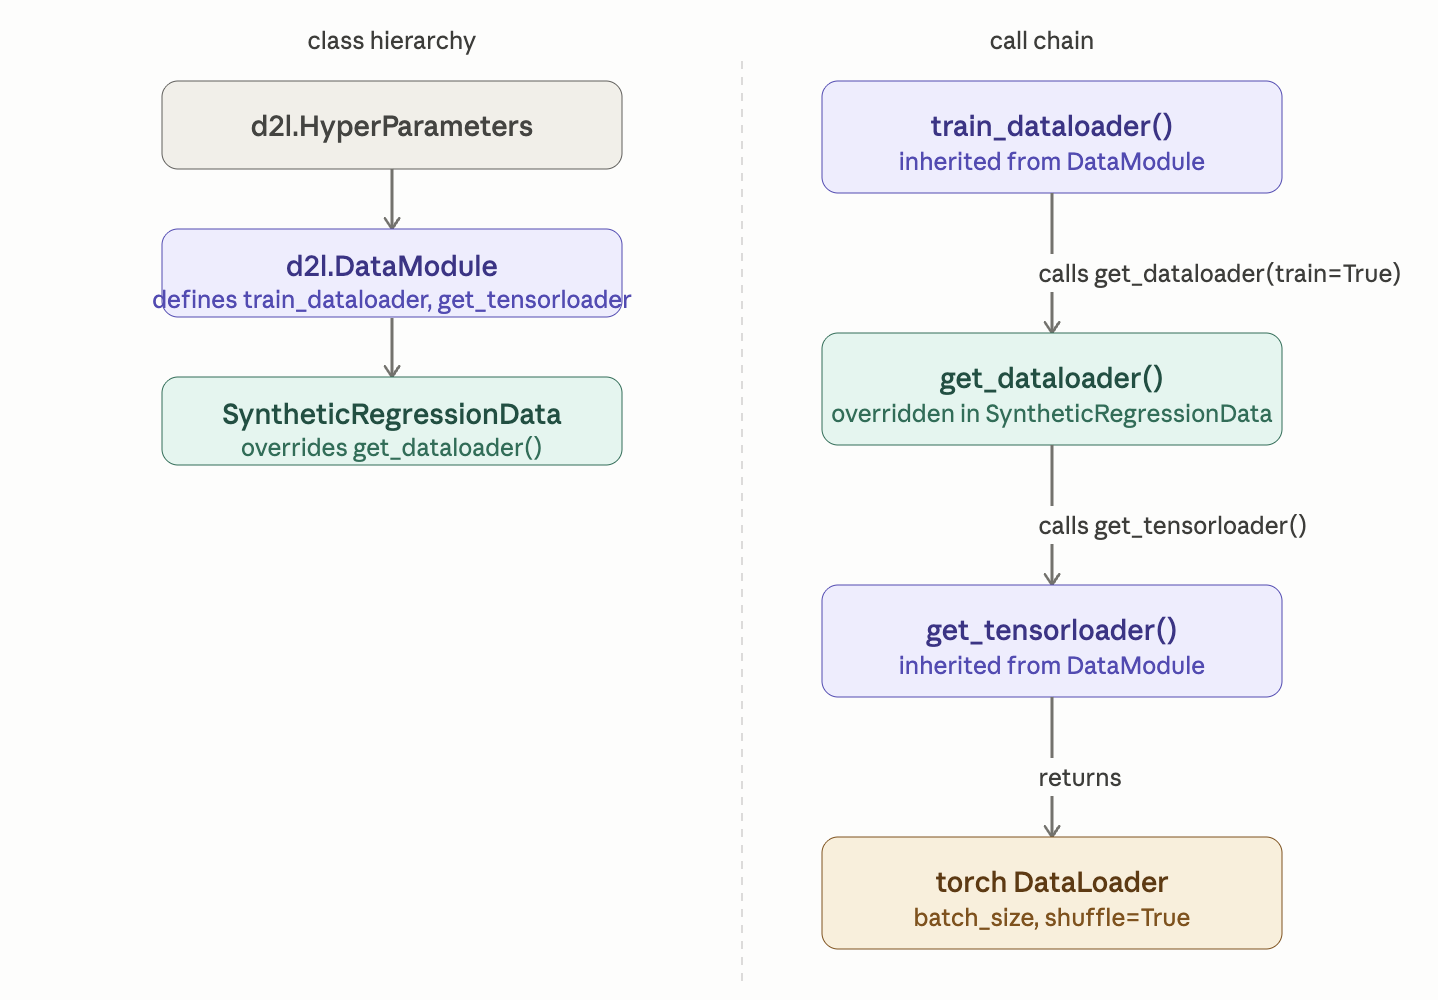

This requires revisiting!


## 3.3.3 Concise Implementation of the Data Loader



First we beef up the `d2l.DataModule` and `SyntheticRegressionData` classes:


In [82]:

@d2l.add_to_class(d2l.DataModule)
def get_tensorloader(self, tensors, train, indices=slice(0, None)):
    # tensors is a tuple of tensors e.g. (X, y).
    # Apply the same index slice to every tensor in the tuple,
    # so X and y stay aligned (same rows selected from both).
    # Default slice(0, None) means "take everything" if no subset needed.
    tensors = tuple(a[indices] for a in tensors)

    # TensorDataset bundles the tensors together so that indexing it
    # returns the i-th row from each tensor simultaneously — i.e. it
    # keeps (x^(i), y^(i)) pairs intact.
    dataset = torch.utils.data.TensorDataset(*tensors)

    # Wrap in a DataLoader, which handles:
    #   - splitting into minibatches of size self.batch_size
    #   - shuffling each epoch if train=True (no shuffling for validation)
    return torch.utils.data.DataLoader(dataset, self.batch_size,
                                       shuffle=train)


@d2l.add_to_class(SyntheticRegressionData)
def get_dataloader(self, train):
    # Select the training rows or the validation rows using a slice.
    # The dataset is laid out as: rows 0..num_train = training data,
    # rows num_train..end = validation data.
    i = slice(0, self.num_train) if train else slice(self.num_train, None)

    # Delegate to get_tensorloader (defined above on DataModule),
    # passing the full X and y tensors plus the appropriate row slice.
    return self.get_tensorloader((self.X, self.y), train, i)

In [83]:
X, y = next(iter(data.train_dataloader()))
print('X shape:', X.shape, '\ny shape:', y.shape)

X shape: torch.Size([32, 2]) 
y shape: torch.Size([32, 1])


We now have a built in __len__ method:

In [84]:
len(data.train_dataloader())

32

## 3.4 Linear Regression from Scratch, again

Fangen wir an. Off we go. Vámanos.



In [81]:
%matplotlib inline
import torch
from d2l import torch as d2l

In [86]:
class LinearRegressionScratch(d2l.Module):
    """The linear regression model implemented from scratch."""

    def __init__(self, num_inputs, lr, sigma=0.01):
        # Call the parent class (d2l.Module) constructor first — mandatory
        # when subclassing in Python so the parent sets itself up properly
        super().__init__()

        # save_hyperparameters() is a d2l convenience method that removes
        # the need to manually assign constructor arguments to self.
        #
        # Normally you would have to write:
        #     self.num_inputs = num_inputs
        #     self.lr = lr
        #     self.sigma = sigma
        #
        # save_hyperparameters() does all of that automatically by
        # inspecting the arguments that were passed to __init__ and
        # assigning each one as an attribute on self.
        #
        # After this line, the following all work:
        #     self.num_inputs  →  whatever was passed as num_inputs
        #     self.lr          →  whatever was passed as lr
        #     self.sigma       →  0.01 (or whatever was passed)
        #
        # It is purely a shortcut — no new information is created,
        # it just saves you writing one line per hyperparameter.
        self.save_hyperparameters()

        # Initialise the weight vector w with shape (num_inputs, 1).
        # Values drawn from N(0, sigma) — small random values to break
        # symmetry. requires_grad=True tells PyTorch to track gradients
        # through w so we can update it via backprop.
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)

        # Initialise the bias scalar b to zero.
        # A single-element tensor; also needs requires_grad=True so
        # PyTorch includes it in the computation graph for gradient descent.
        self.b = torch.zeros(1, requires_grad=True)

Ok, wait a minute. Remind me about `save_hyperparameters`:

In [88]:
import inspect
print(inspect.getsource(d2l.HyperParameters))

class HyperParameters:
    """The base class of hyperparameters."""
    def save_hyperparameters(self, ignore=[]):
        """Defined in :numref:`sec_oo-design`"""
        raise NotImplemented

    def save_hyperparameters(self, ignore=[]):
        """Save function arguments into class attributes.
    
        Defined in :numref:`sec_utils`"""
        frame = inspect.currentframe().f_back
        _, _, _, local_vars = inspect.getargvalues(frame)
        self.hparams = {k:v for k, v in local_vars.items()
                        if k not in set(ignore+['self']) and not k.startswith('_')}
        for k, v in self.hparams.items():
            setattr(self, k, v)



All right then. Next ...


## 3.4.1 Defining a Model

In [92]:
@d2l.add_to_class(LinearRegressionScratch)
def forward(self, X):
    # This is the forward pass — given input data X, compute predictions.
    # Implements y_hat = Xw + b in matrix form.
    #
    # X has shape (batch_size, num_inputs)
    # self.w has shape (num_inputs, 1)
    # torch.matmul(X, self.w) gives shape (batch_size, 1) — one prediction per row
    # adding self.b broadcasts the scalar bias across all predictions
    #
    # In PyTorch, forward() is called automatically when you do model(X),
    # so you never call this method directly.
    return torch.matmul(X, self.w) + self.b

## 3.4.2 Defining a Loss Function



In [91]:
@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    # Computes the mean of the per-sample squared error loss:
    #   l^(i) = (y_hat^(i) - y^(i))^2 / 2
    #
    # The /2 is the notational convenience from the textbook — it cancels
    # the 2 that appears when you differentiate (y_hat - y)^2, leaving a
    # clean gradient of (y_hat - y) rather than 2*(y_hat - y).
    #
    # y_hat and y both have shape (batch_size, 1), so l has the same shape
    # — one loss value per sample in the minibatch.
    l = (y_hat - y) ** 2 / 2

    # Average the per-sample losses across the minibatch to get a single
    # scalar loss value — this is L(w, b) from the textbook.
    return l.mean()

## 3.4.3 Definiting an Optimisation Algorithm

Here we use stochastic gradient descent, minibatch version. Or minibatch SGD for short.


In [94]:
class SGD(d2l.HyperParameters):
    """Minibatch stochastic gradient descent."""

    def __init__(self, params, lr):
        # params: a list of tensors to be updated (e.g. [self.w, self.b])
        # lr: the learning rate eta
        # save_hyperparameters() assigns both as self.params and self.lr
        self.save_hyperparameters()

    def step(self):
        # Apply one gradient descent update to every parameter.
        # For each parameter tensor, subtract lr * gradient:
        #   param ← param - eta * d(loss)/d(param)
        # This is the update rule from the textbook:
        #   w ← w - (eta / |B|) * sum of gradients
        # Note: the 1/|B| normalisation already happened inside loss.mean(),
        # so param.grad here already contains the averaged gradient.
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        # After each update, PyTorch accumulates gradients by default —
        # i.e. the next backward() call ADDS to whatever is already in
        # param.grad rather than replacing it. This would corrupt the
        # gradients across minibatches, so we must zero them out before
        # each new forward/backward pass.
        # The trailing underscore in zero_() means in-place operation.
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

Next we define the `configure_optimizers` method, which returns an instance of the SGD class:

In [96]:
@d2l.add_to_class(LinearRegressionScratch)
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

## 3.4.4 Training

Now we have all the parts: parameters, loss function, model, and optimizer (I will finally give in here to American spelling as the method uses it).



In [98]:
@d2l.add_to_class(d2l.Trainer)
def prepare_batch(self, batch):
    # A hook for preprocessing each batch before it is passed to the model.
    # Here it is a no-op — the batch is returned unchanged.
    # Subclasses can override this to move data to GPU, cast dtypes, etc.
    return batch

@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    # Executes one full epoch of the training loop described in Section 3.4.4:
    #
    #   Initialise parameters (w, b)                   ← done before fit_epoch
    #   Repeat until done:
    #     g ← d/d(w,b) [ 1/|B| * sum_{i in B} l(x^i, y^i, w, b) ]
    #     (w, b) ← (w, b) - eta * g
    #
    # One epoch = one full pass through the training data (assuming n is
    # divisible by batch size), followed by one pass through validation.

    # ── Training loop ──────────────────────────────────────────────────

    # Put the model in training mode. This matters for layers like dropout
    # and batch normalisation that behave differently during training vs
    # evaluation. Has no effect on our simple linear model, but good practice.
    self.model.train()

    for batch in self.train_dataloader:
        # One iteration: grab a minibatch B and compute its loss.
        # This is the training_step method on the model, which calls
        # forward() then loss() — i.e. computes 1/|B| * sum l^(i).
        loss = self.model.training_step(self.prepare_batch(batch))

        # Clear gradients from the previous iteration. If we didn't do this,
        # PyTorch would accumulate gradients across batches, corrupting updates.
        self.optim.zero_grad()

        # torch.no_grad() tells PyTorch not to build a computation graph for
        # the operations inside this block — we don't need gradients of
        # gradients, so this saves memory and computation.
        with torch.no_grad():
            # Compute gradient g ← d/d(w,b) [ 1/|B| * sum l^(i) ]
            # PyTorch walks the computation graph and fills w.grad and b.grad.
            loss.backward()

            # Optionally clip gradients to prevent exploding gradients.
            # Not relevant for linear regression — covered later in the book.
            if self.gradient_clip_val > 0:
                self.clip_gradients(self.gradient_clip_val, self.model)

            # Update parameters: (w, b) ← (w, b) - eta * g
            # i.e. w -= lr * w.grad,  b -= lr * b.grad
            self.optim.step()

        # Track how many training batches have been processed in total
        # across all epochs — used for plotting and logging.
        self.train_batch_idx += 1

    # ── Validation loop ────────────────────────────────────────────────

    # The synthetic dataset from Section 3.3 has no validation set by default.
    # In general we want one, so if it exists we pass through it once per epoch
    # to measure model quality without updating any parameters.
    if self.val_dataloader is None:
        return

    # Put the model in evaluation mode — disables dropout, batch norm etc.
    self.model.eval()

    for batch in self.val_dataloader:
        with torch.no_grad():
            # Forward pass only — no backward pass, no parameter updates.
            # Just compute validation loss to monitor generalisation.
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

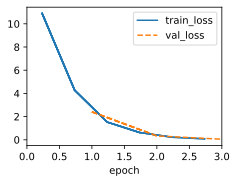

In [99]:
# Instantiate the model with 2 input features and learning rate 0.03.
# Internally this initialises w as a (2,1) tensor from N(0, 0.01)
# and b as a zero tensor, both with requires_grad=True.
model = LinearRegressionScratch(2, lr=0.03)

# Generate a synthetic dataset with known true parameters:
#   y = 2*x1 - 3.4*x2 + 4.2 + epsilon,  epsilon ~ N(0, 1)
# Since we know the true w and b, we can directly check how well
# the model recovers them after training.
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)

# Create a Trainer that will run for 3 epochs.
# The Trainer owns the training loop — it calls fit_epoch() once
# per epoch, which handles the minibatch iteration, forward pass,
# backward pass, and parameter updates.
trainer = d2l.Trainer(max_epochs=3)

# Kick off training: for each of 3 epochs, iterate through all
# minibatches, compute gradients, and update w and b via SGD.
# After 3 epochs we expect w and b to be close to [2, -3.4] and 4.2.
trainer.fit(model, data)

In [104]:
import pandas as pd

# Inside this block, don't track gradients for any operation
with torch.no_grad():
    w_true = data.w.numpy()
    w_est  = model.w.reshape(data.w.shape).numpy()
    b_true = float(data.b)
    b_est  = float(model.b)

    rows = []
    for i, (true, est) in enumerate(zip(w_true, w_est)):
        diff = true - est
        pct  = 100 * diff / true
        rows.append({'Parameter': f'w[{i}]', 'True': f'{true:.4f}',
                     'Estimated': f'{est:.4f}', 'Difference': f'{diff:.4f}',
                     '% Difference': f'{pct:.2f}%'})

    diff_b = b_true - b_est
    pct_b  = 100 * diff_b / b_true
    rows.append({'Parameter': 'b', 'True': f'{b_true:.4f}',
                 'Estimated': f'{b_est:.4f}', 'Difference': f'{diff_b:.4f}',
                 '% Difference': f'{pct_b:.2f}%'})

    df = pd.DataFrame(rows).set_index('Parameter')
    display(df.round(2))

,True,Estimated,Difference,% Difference
Parameter,,,,
w[0],2.0000,1.8859,0.1141,5.70%
w[1],-3.4000,-3.2142,-0.1858,5.46%
b,4.2000,3.9863,0.2137,5.09%


## 3.5 Concise Implementation of Linear Regression

Now for the API implementation:

In [112]:
!pip install --no-deps d2l

In [113]:
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

## 3.5.1 Defining the Model

In [114]:
class LinearRegression(d2l.Module):
    """The linear regression model implemented with high-level APIs."""

    def __init__(self, lr):
        super().__init__()

        # Save lr as self.lr via the d2l convenience method.
        self.save_hyperparameters()

        # nn.LazyLinear is PyTorch's "lazy" version of nn.Linear.
        # The 1 means there is 1 output (a single scalar y_hat per sample).
        # It is "lazy" because we don't specify the number of input features
        # here — PyTorch infers it automatically from the shape of the first
        # batch of data it sees, so we don't need to pass num_inputs manually.
        # Compare with LinearRegressionScratch where we had to pass num_inputs=2.
        self.net = nn.LazyLinear(1)

        # Initialise the weight matrix with small random values from N(0, 0.01).
        # The trailing underscore means this is an in-place operation —
        # PyTorch convention for methods that modify a tensor directly.
        self.net.weight.data.normal_(0, 0.01)

        # Initialise the bias to zero, again in-place.
        self.net.bias.data.fill_(0)



In [115]:
@d2l.add_to_class(LinearRegression)
def forward(self, X):
    # Pass X through the nn.LazyLinear layer, which computes Xw + b
    # internally. This is the high-level API equivalent of the manual
    # torch.matmul(X, self.w) + self.b in LinearRegressionScratch.
    # PyTorch calls this method automatically when you do model(X).
    return self.net(X)

## 3.5.2 Defining the Loss Function

In [116]:
"""The MSELoss class computes the mean squared error
(without the 1/2 factor in (3.1.5)).
 By default, MSELoss returns the average loss over examples.
 It is faster (and easier to use) than implementing our own.
"""
@d2l.add_to_class(LinearRegression)
def loss(self, y_hat, y):
    fn = nn.MSELoss()
    return fn(y_hat, y)

## 3.5.3 Defining the Optimisation Algorithm



In [117]:
@d2l.add_to_class(LinearRegression)
def configure_optimizers(self):
    # Returns a PyTorch built-in SGD optimizer configured with:
    #   - self.parameters(): all trainable parameters in the model
    #     (i.e. self.net.weight and self.net.bias) — this is a method
    #     inherited from nn.Module that automatically finds them all
    #   - self.lr: the learning rate saved by save_hyperparameters()
    #
    # This is the high-level equivalent of our hand-rolled SGD class,
    # which had to be passed [self.w, self.b] explicitly. Here nn.Module
    # tracks the parameters for us automatically.
    return torch.optim.SGD(self.parameters(), self.lr)

## 3.5.4 Training

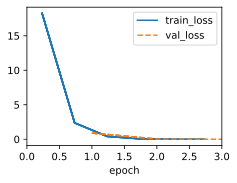

In [118]:
model = LinearRegression(lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

In [119]:
@d2l.add_to_class(LinearRegression)
def get_w_b(self):
    return (self.net.weight.data, self.net.bias.data)

w, b = model.get_w_b()

with torch.no_grad():
    w_true = data.w.numpy()
    w_est  = w.reshape(data.w.shape).numpy()
    b_true = float(data.b)
    b_est  = float(b)

    rows = []
    for i, (true, est) in enumerate(zip(w_true, w_est)):
        diff = true - est
        pct  = 100 * diff / true
        rows.append({'Parameter': f'w[{i}]', 'True': f'{true:.4f}',
                     'Estimated': f'{est:.4f}', 'Difference': f'{diff:.4f}',
                     '% Difference': f'{pct:.2f}%'})

    diff_b = b_true - b_est
    pct_b  = 100 * diff_b / b_true
    rows.append({'Parameter': 'b', 'True': f'{b_true:.4f}',
                 'Estimated': f'{b_est:.4f}', 'Difference': f'{diff_b:.4f}',
                 '% Difference': f'{pct_b:.2f}%'})

    df = pd.DataFrame(rows).set_index('Parameter')
    display(df)

,True,Estimated,Difference,% Difference
Parameter,,,,
w[0],2.0000,1.9860,0.0140,0.70%
w[1],-3.4000,-3.3923,-0.0077,0.23%
b,4.2000,4.1854,0.0146,0.35%


## 3.6 Generalisation

The problem of inference from data from the past and today to predict tomorrow.

"Whenever we work with finite samples, we must keep in mind the risk that we might fit our training data, only to discover that we failed to discover a generalizable pattern."

"The phenomenon of fitting closer to our training data than to the underlying distribution is called overfitting, and techniques for combatting overfitting are often called regularization methods."

## 3.6.1 Training Error and Generalisation Error

Continuing the notation from the beginning of the chapter, the training error is given by:

$$R_{\text{empirical}}[\mathbf{X}, \mathbf{y}, f] = \frac{1}{n} \sum_{i=1}^{n} l(\mathbf{x}^{(i)}, y^{(i)}, f(\mathbf{x}^{(i)}))$$

While the generalisation error is expressed as an integral:

$$R[p, f] = E_{(\mathbf{x}, y) \sim P}[l(\mathbf{x}, y, f(\mathbf{x}))] = \iint l(\mathbf{x}, y, f(\mathbf{x})) p(\mathbf{x}, y) \, d\mathbf{x} \, dy$$

### 3.6.1.1 Model complexity

Abundant data and simple models $\rightarrow$ training and generalisation errors tend to be close

Fewer examples and/or complex models $\rightarrow$ training error goes down but the generalisation gap can grow.

Critically, low training error does **not** necessarily imply low generalisation error. (Nor high generalisation error.)

Neural networks turn out to be just such models. Hence it is critical to test them on a validation set and calculate the *validation error*.

## 3.6.2 Underfitting or Overfitting

### 3.6.2.1 Polynomial Curve Fitting

### 3.6.2.2 Dataset Size

The fewer samples we have in the training dataset, the more likely (and more severely) we are to encounter overfitting.

For many tasks, deep learning only outperforms linear models when many thousands of training examples are available.



## 3.6.3 Model Selection

"In principle, we should not touch our test set until after we have chosen all our hyperparameters. Were we to use the test data in the model selection process, there is a risk that we might overfit the test data. Then we would be in serious trouble. If we overfit our training data, there is always the evaluation on test data to keep us honest. But if we overfit the test data, how would we ever know?"

In the distinction between test, training, and validation datasets:

- **Training set**: used to fit the model parameters (**w**, $b$) via gradient descent
- **Validation set**: used to tune hyperparameters (learning rate, batch size, number of epochs, model architecture, etc.) — you train on the training set, check performance on the validation set, adjust hyperparameters, repeat
- **Test set**: used only once, at the very end, to get an honest estimate of generalisation error — it should never influence any decision during model development

The reason the test set must stay completely untouched during development is that if you use it to make decisions (even hyperparameter choices), you have effectively trained on it indirectly, and your final error estimate will be optimistically biased.

### 3.6.3.1 Cross-Validation

One strategy is *K-fold cross-validation*. Data is divided into $K$ non overlapping subsets. The model is trained on $K - 1$ of the subsets and validated on the other. Training and validation errors are estimated by averaging over the results from the $K$ experiments.



## 3.7 Weight Decay

